<a href="https://colab.research.google.com/github/NEBUSALIM/SharePricePredictor/blob/main/maruti_30min_prediction_v1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Input shape: (280, 20, 5), Target shape: (280, 4)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.3380 - val_loss: 0.3009
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2426 - val_loss: 0.1789
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1054 - val_loss: 0.0141
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0555 - val_loss: 0.0259
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0277 - val_loss: 0.0109
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0196 - val_loss: 0.0043
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0195 - val_loss: 0.0065
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0160 - val_loss: 0.0048
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0138 - val_loss: 0.0033
Epoch 10/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0114 - val_loss: 0.0030
Epoch 11/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0102 - val_loss: 0.0022
Epoch 12/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0104 - val_loss: 0.0020
E

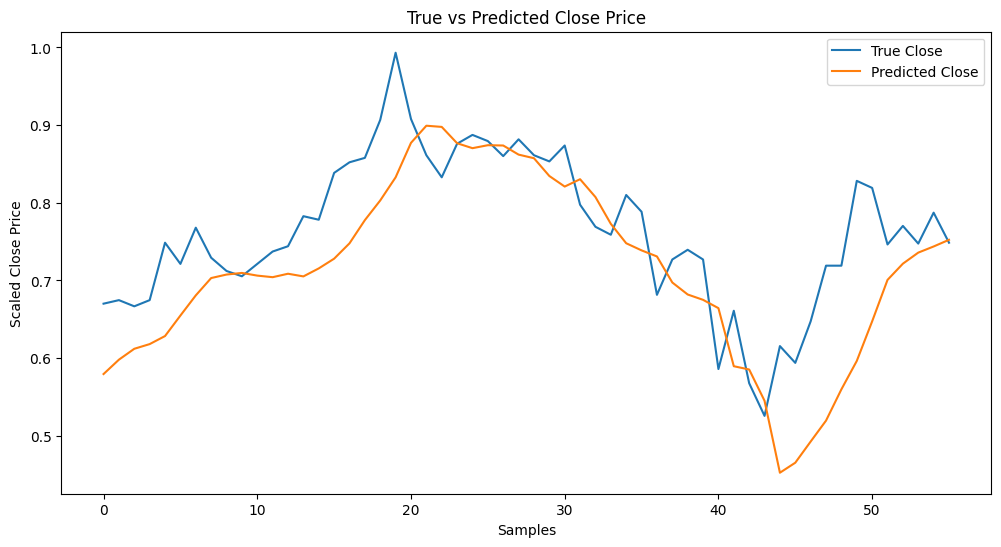


🔮 Predicting the Next 30-min Candle:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Open  : 11826.17
Predicted High  : 11846.63
Predicted Low   : 11794.93
Predicted Close : 11817.10


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_excel('MARUTI-OHLC-30min-Data-20Mar2025(3.15PM)-28Apr2025(3.15PM).xlsx')

# Parse the date format
df['time'] = pd.to_datetime(df['time'], format='%d %b %y %I:%M %p')
df = df.sort_values('time').reset_index(drop=True)

# 2. Clean Volume Column
def clean_volume(volume_str):
    """Convert 'K', 'M', etc. format into actual numbers."""
    if isinstance(volume_str, str):
        volume_str = volume_str.replace(',', '')  # Remove commas if any
        if 'K' in volume_str:
            return float(volume_str.replace('K', '')) * 1000
        elif 'M' in volume_str:
            return float(volume_str.replace('M', '')) * 1000000
        elif 'B' in volume_str:
            return float(volume_str.replace('B', '')) * 1000000000
        else:
            return float(volume_str)
    return volume_str

# Apply the function to the Volume column
df['Volume'] = df['Volume'].apply(clean_volume)

# 3. Feature Columns
feature_cols = ['open', 'high', 'low', 'close', 'Volume']

# 4. Scaling Features
scaler = MinMaxScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# 5. Create Sequences
n_past = 20  # Use past 20 candles
n_future = 1  # Predict next 1 candle

X, y = [], []

for i in range(n_past, len(df) - n_future + 1):
    X.append(df[feature_cols].iloc[i - n_past:i].values)
    y.append(df[['open', 'high', 'low', 'close']].iloc[i + n_future - 1].values)

X = np.array(X)
y = np.array(y)

print(f"Input shape: {X.shape}, Target shape: {y.shape}")

# 6. Train/Test Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 7. Build LSTM Model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(n_past, len(feature_cols))),
    Dense(32, activation='relu'),
    Dense(4)  # Predict OHLC
])

model.compile(optimizer='adam', loss='mse')

# 8. Train the model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1)

# 9. Evaluate
loss = model.evaluate(X_test, y_test)
print(f"\n📉 Test Loss (MSE): {loss:.6f}")

# 10. Predict on Test Data
y_pred = model.predict(X_test)

# 11. Plot True vs Predicted Close Price
plt.figure(figsize=(12, 6))
plt.plot(y_test[:, 3], label='True Close')
plt.plot(y_pred[:, 3], label='Predicted Close')
plt.legend()
plt.title('True vs Predicted Close Price')
plt.xlabel('Samples')
plt.ylabel('Scaled Close Price')
plt.show()

# 12. Predict the Next 30-min Candle (LIVE)
print("\n🔮 Predicting the Next 30-min Candle:")

# Prepare latest 20 candles
latest_sequence = df[feature_cols].iloc[-n_past:].values
latest_sequence = np.expand_dims(latest_sequence, axis=0)  # (1, 20, 5)

# Predict
predicted_candle_scaled = model.predict(latest_sequence)

# Inverse transform back to real scale
temp = np.zeros((1, len(feature_cols)))
temp[0, :4] = predicted_candle_scaled
predicted_candle = scaler.inverse_transform(temp)[0][:4]

predicted_open, predicted_high, predicted_low, predicted_close = predicted_candle

print(f"Predicted Open  : {predicted_open:.2f}")
print(f"Predicted High  : {predicted_high:.2f}")
print(f"Predicted Low   : {predicted_low:.2f}")
print(f"Predicted Close : {predicted_close:.2f}")
